# XLEAP Detector

This notebook detects XLEAP using undulator taper, and quantifies the taper in MeV/fs, and reports which undulators are lasing.

## Theory

**Reference:** [K.-J. Kim, Z. Huang, and R. Lindberg, “Undulator Radiation,” in *Synchrotron Radiation and Free-Electron Lasers: Principles of Coherent X-Ray Generation*, Cambridge: Cambridge University Press, 2017, pp. 43–45](https://www.cambridge.org/core/books/synchrotron-radiation-and-freeelectron-lasers/F90638BB364B5A3EF9A78978CE15B1A5)

In an undulator with magnetic field strength $B_0$ and wavenumber $k_u$, the electrons encounter a magnetic field in $\hat y$

$$
\vec{B}_u = B_0 \sin(k_u z) \hat y
$$

that produces a force in $\hat x$:

$$
\begin{align*}
\dot {\vec p} = \partial_t (\gamma mc \vec \beta)&= -e (\xcancel{\vec E} + \vec v \times \vec B) \\
&= -e(\beta c \hat z) \times B_0 \sin(k_u z) \hat y \\
&= +e\beta c B_0 \sin(k_u z) \hat x \\
\end{align*}
$$
Neglecting energy losses from steering radiation, we take $\dot \gamma = 0$ and integrate (taking $\beta_x = 0$ at $t=0$ from before the undulator) to find $\beta_x$:
$$
\begin{align*}
\dot \beta_x &= \frac{e \beta c B_0}{\gamma m c} \sin(k_u z) = \frac{e \beta B_0}{\gamma m} \sin(k_u \beta c t) \tag{$\beta_z \approx \beta \lesssim 1$} \\
\beta_x &= \left. \frac{e \beta B_0}{\gamma m k_u \beta c} \cos(k_u \beta c t)\right \vert_0^t = \frac{e B_0}{\gamma k_u m c} \cos(k_u \beta c t) - 0 = \frac{1}{\gamma}{\frac{e B_0}{k_u m c}}\cos(k_u z)  \\ 
\beta_x &= \frac{K}{\gamma} \cos(k_u z) \; \llap{\boxed{\phantom{\beta_x = \frac{K}{\gamma} \cos(k_u z)}}} \tag{$K \coloneqq {e B_0}/{k_u m c}$}

\end{align*}
$$

Again neglecting energy losses from steering radiation, we say that energy $\gamma mc^2$ and therefore total velocity $\beta$ is conserved from before the undulator, but once inside the undulator, the velocity is split between $x$ and $z$ components:

$$
\begin{align*}
{\vec \beta}^2 &= \beta_z^2 + \beta_x^2 \\
\beta_z^2 &= \vec \beta^2 - \beta_x^2 = \left(1 - \frac {1}{\gamma^2} \right) - \beta_x^2 \\
\beta_z &= \sqrt{1-\frac{1}{\gamma^2}-\beta_x^2} \\ 
&\approx 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\cos^2(k_u z) \tag{$\sqrt{1-\varepsilon}\approx 1-\varepsilon/2$} \\
\left\langle \beta_z \right\rangle &= 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\left\langle\cos^2({k_u z})\right\rangle = 1- \frac{1}{2\gamma^2} - \frac{K^2}{4\gamma^2} \\
\left\langle \beta_z \right\rangle &= 1- \left(\frac{1+K^2/2}{2\gamma^2}\right) \; \llap{\boxed{\phantom{\left\langle \beta_z \right\rangle = 1- \left(\frac{1+K^2/2}{2\gamma^2}\right)}}} 
\end{align*}
$$
Therefore, the radiation emitted by the electrons is faster than the electrons themselves by $\Delta \beta \coloneqq 1-\left\langle \beta_z \right\rangle = (1+K^2/2)/2\gamma^2$. 

The electrons now experience fields due to both the undulator magnets and their own radiation. To achieve resonance, these contributions must be in phase, so the radiation must slip ahead of the electrons by one radiation wavelength $\lambda_r$ per undulator period $\lambda_u$. Light traverses an undulator period in time $T = \lambda_u/c$, during which time the electrons fall behind by a distance $\Delta \beta c T = \lambda_u(1+K^2/2)/2\gamma^2$, called the **slippage length**. Therefore we set the radiation wavelength equal to one slippage length:
$$
\boxed{\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)}
$$

Meanwhile, space charge forces create an energy spread within the current spike by pushing head electrons forward and tail electrons backward, so the radiation slips ahead from lower-energy to higher-energy slices of electrons: $\gamma \to \gamma + \Delta \gamma$. Due to the taper, $K$ also increases downstream: $K \to K + \Delta K$. To maintain resonance, we now need
$$
\lambda_r = \frac{\lambda_u}{2(\gamma + \Delta \gamma)^2}\left(1+\frac{(K + \Delta K)^2}{2}\right)
$$

Therefore, given a $\Delta K$ between two undulators, we can find the corresponding $\Delta \gamma$ needed to maintain resonance:
$$
\begin{align*}
\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right) &= \frac{\lambda_u}{2(\gamma+\Delta \gamma)^2}\left(1+\frac{(K+\Delta K)^2}{2}\right) \\
\implies \Delta \gamma &= \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right) \; \llap{\boxed{\phantom{\Delta \gamma = \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right)}}} \approx \gamma\left(\frac{K\Delta K + \Delta K^2/2}{K^2+2}\right) 
\end{align*}
$$

Finally, we define *undulator taper* as change in resonant energy $\gamma$ per slippage length $\lambda_r$. Since we find $\Delta K$ between undulators and we get $N_u = L_u/\lambda_u$ periods per undulator ($L_u = 3.4 \text{ m}$), we divide $\Delta \gamma$ by the total slippage in one undulator $\Delta s \coloneqq N_u \lambda_r$. However, we write the slippage length in units of time, $N_u \lambda_r/c$, so that we can write the result in MeV/fs.
$$
\mathrm{taper} \coloneqq \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

Surprisingly, $\lambda_u$ cancels, so we can get the taper from the list of $K$ values (which also gives $\Delta K \to \Delta \gamma$), the beam energy $\gamma$, and the length of an undulator $L_u = 3.4\text{ m}$. 

## Implementation

We calculate the taper every 15 minutes between `start` and `end` times.
We are interested in three things:
1. Whether XLEAP is happening, indicated by the presence of at least one lasing group of tapered undulators;
2. Which undulators are lasing, as a boolean array (or number of undulators, if we sum);
3. The undulator taper as energy gain per slippage length in MeV/fs, calculated by:
    
    a) taking the median of the sorted list of $\Delta K$ within the lasing group, 
    
    b) converting to $\Delta \gamma$ using the first $K$ value of the first lasing undulator group, and
    
    c) dividing by the total slippage in a single undulator in units of time: $\Delta s = N_u \lambda_r/c$


In [1]:
import os, re
import numpy as np
from datetime import timedelta, datetime as dt
from pathlib import Path

from sparklines.app.xleap_snapshot_store import DEFAULT_DB_PATH, connect

start = dt(2026, 6, 1, 0, 0)
end = dt.now()
sample_delta = timedelta(minutes=15)
snapshot_delta = timedelta(seconds=3)


## Data collection

We take the length of an undulator $L_u$ as 3.4 m, ignoring the spaces between undulators since negligible slippage occurs without the magnetic field bleeding $\beta_z$ into $\beta_x$.

We get $\gamma$ from the beam dump PV `BEND:DMPS:400:BACT`. This reports the strength of the beam dump magnet not in teslas, but as the beam momentum it is tuned to deflect. This momentum $p$ is given in units of **GeV/c**. We solve for $\gamma$ via $E = \gamma mc^2 = \sqrt{p^2c^2 + m^2c^4} \implies \gamma = \sqrt{(pc/mc^2)^2+1}$. However, since $pc \gg mc^2$, we have roughly $\gamma = pc/mc^2$, so we can basically read off $\gamma$ by dividing `BEND:DMPS:400:BACT` in GeV by $mc^2 = 0.511\text{ MeV}$.

Finally, we take a snapshot of the series of undulator $K$ values. We take $K$ as the first $K$ in the most upstream "hockey stick" region, that is, a group of at least 4 undulators whose $K$'s are increasing by at least $4\rho$ per undulator. These are discovered by binary erosion, explained in the code below. 

After discovering a "lasing group," we also check whether the undulators are moving by enforcing $\Delta K/K < 10^{-3}$, where $\Delta K$ in this case is not between undulators, but between archived values for the same undulator within the 5-second snapshot. If there is a unique K within the interval (or before it), we assume the undulator is stationary. We throw out time points with ANY moving undulators.



In [2]:
SNAPSHOT_DB_PATH = DEFAULT_DB_PATH
GAMMA_PV = 'BEND:DMPS:400:BACT'
KACT_PV_RE = re.compile(r'USEG:UNDS:(\d+):KAct')
SQLITE_MAX_VARIABLES = 900


def _normalize_pv_names(pv_names):
    if isinstance(pv_names, str):
        return [pv_names]
    return list(pv_names)


def _quote_sqlite_identifier(identifier):
    return '"' + identifier.replace('\"', '""') + '"'


def _snapshot_time_key(time):
    return time.replace(microsecond=0).isoformat()


def _chunked(items, chunk_size):
    for start_index in range(0, len(items), chunk_size):
        yield items[start_index:start_index + chunk_size]


def _snapshot_pvs_from_sqlite(pattern=None, db_path=SNAPSHOT_DB_PATH):
    with connect(db_path) as connection:
        rows = connection.execute(
            "PRAGMA table_info(snapshot_values_wide)"
        ).fetchall()

    pv_names = [row[1] for row in rows if row[1] != 'nominal_time']
    if pattern is None:
        return pv_names
    return [pv for pv in pv_names if pattern.fullmatch(pv)]


def _fetch_wide_table_rows(table_name, pv_names, time_keys, connection):
    if not pv_names or not time_keys:
        return {}

    quoted_table = _quote_sqlite_identifier(table_name)
    quoted_pvs = [_quote_sqlite_identifier(pv) for pv in pv_names]
    selected_columns = ', '.join(['nominal_time', *quoted_pvs])
    rows_by_time = {}
    max_times_per_query = max(1, SQLITE_MAX_VARIABLES)

    for chunk in _chunked(time_keys, max_times_per_query):
        placeholders = ', '.join(['?'] * len(chunk))
        rows = connection.execute(
            f"""
            SELECT {selected_columns}
            FROM {quoted_table}
            WHERE nominal_time IN ({placeholders})
            """,
            chunk,
        ).fetchall()
        for row in rows:
            rows_by_time[row[0]] = row[1:]

    return rows_by_time


def _fetch_sqlite_snapshots(pv_names, times, *, db_path=SNAPSHOT_DB_PATH, fetch_missing=False):
    if fetch_missing:
        raise ValueError('fetch_missing=True would require archiver access; populate the SQLite DB first')

    pv_names = _normalize_pv_names(pv_names)
    time_keys = [_snapshot_time_key(time) for time in times]
    with connect(db_path) as connection:
        values_by_time = _fetch_wide_table_rows(
            'snapshot_values_wide', pv_names, time_keys, connection
        )
        timestamps_by_time = _fetch_wide_table_rows(
            'snapshot_timestamps_wide', pv_names, time_keys, connection
        )

    snapshots = []
    for time_key in time_keys:
        values = values_by_time.get(time_key)
        timestamps = timestamps_by_time.get(time_key)
        if values is None or timestamps is None:
            snapshots.append({})
            continue

        snapshot = {}
        for pv, timestamp, value in zip(pv_names, timestamps, values):
            if timestamp is None or value is None:
                continue
            snapshot[pv] = (dt.fromisoformat(timestamp), float(value))
        snapshots.append(snapshot)

    return snapshots


def _fetch_sqlite_snapshot(pv_names, nominal_time, *, db_path=SNAPSHOT_DB_PATH):
    return _fetch_sqlite_snapshots(pv_names, [nominal_time], db_path=db_path)[0]


In [3]:
# Test: read a gamma snapshot from SQLite
_fetch_sqlite_snapshot([GAMMA_PV], start)


{'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 0, 2),
  10.000011194073167)}

### $\gamma$

In [4]:
gamma_times = []
t = start
while t < end:
    gamma_times.append(t)
    t += sample_delta

gamma_snapshots = _fetch_sqlite_snapshots(GAMMA_PV, gamma_times)


In [22]:
gamma_snapshots

[{'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   10.000011194073167)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 15, 2),
   9.99999586339207)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 30, 2),
   10.000010870071822)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 45, 2),
   10.000000497319364)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 1, 0, 2),
   10.000004704804068)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 1, 15, 2),
   9.999998798457275)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 1, 30, 1),
   9.999987000987506)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 1, 45, 2),
   9.999999333250791)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 2, 0, 2),
   9.999996722140034)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 2, 15, 2),
   10.000001384273258)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 2, 30, 2),
   10.00000491734956)},
 {'BEND:D

### $K$

In [23]:
kact_pvs = _snapshot_pvs_from_sqlite(KACT_PV_RE)
und_nums = [KACT_PV_RE.fullmatch(pv).group(1) for pv in kact_pvs]

k_times = []
t = start
while t < end:
    k_times.append(t)
    t += sample_delta

k_snapshots = _fetch_sqlite_snapshots(kact_pvs, k_times)


In [24]:
k_snapshots

[{'USEG:UNDS:2150:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.725062129133953),
  'USEG:UNDS:2250:KAct': (datetime.datetime(2026, 6, 1, 0, 0),
   6.72696357135488),
  'USEG:UNDS:2350:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 56),
   6.726536693442391),
  'USEG:UNDS:2450:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724772491594098),
  'USEG:UNDS:2550:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 36),
   6.724057586925176),
  'USEG:UNDS:2650:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.7249611294244485),
  'USEG:UNDS:2750:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724410226463157),
  'USEG:UNDS:2850:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 59),
   6.724680969380071),
  'USEG:UNDS:2950:KAct': (datetime.datetime(2026, 6, 1, 0, 0),
   6.7243741335124305),
  'USEG:UNDS:3050:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 51),
   6.724943444939528),
  'USEG:UNDS:3150:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724673599169667),
  'USEG:UN

## XLEAP detection
We say that XLEAP is happening when:
>There exists a group of at least 4 undulators whose $K$'s are increasing by at least $4\rho$ per undulator ($\rho \sim 0.3$).

To find such a group, we make a boolean array from the K array indicating where $K_{i}\geq K_{i-1}+4\rho$. Then we use "binary erosion" and "binary expansion" to filter for runs of at least $n=4$ consecutive increases of $\Delta K \geq 4\rho$.

In [25]:
# Build a display DataFrame from the K snapshots using nominal request times.
import pandas as pd

und_nums = [re.search(r'USEG:UNDS:(\d+):KAct', pv).group(1) for pv in kact_pvs]
nominal_times = k_times

kvals_df = pd.DataFrame(
    data=[
        [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
        for snapshot in k_snapshots
    ],
    index=nominal_times,
    columns=und_nums,
)
kvals_df.index.name = 'NOMINAL time'
kvals_df.columns.name = 'Undulator'
kvals_df

Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00,6.725062,6.726964,6.726537,6.724772,6.724058,6.724961,6.724410,6.724681,6.724374,6.724943,...,6.718377,6.715974,6.711830,6.704956,1.372594,1.800388,1.321534,1.706796,1.753548,1.608738
2026-06-01 00:15:00,6.725046,6.726992,6.726536,6.724744,6.724065,6.724961,6.724408,6.724663,6.724378,6.724962,...,6.718408,6.716008,6.711852,6.704967,1.372593,1.800389,1.321534,1.706790,1.753540,1.608738
2026-06-01 00:30:00,6.725064,6.727010,6.726513,6.724763,6.724008,6.724957,6.724436,6.724668,6.724381,6.724985,...,6.718442,6.715990,6.711847,6.704936,1.372592,1.800388,1.321528,1.706797,1.753544,1.608739
2026-06-01 00:45:00,6.725059,6.726988,6.726583,6.724732,6.724042,6.724983,6.724403,6.724665,6.724365,6.724951,...,6.718431,6.715988,6.711831,6.704969,1.372594,1.800385,1.321533,1.706800,1.753548,1.608738
2026-06-01 01:00:00,6.725059,6.727001,6.726570,6.724739,6.724042,6.724967,6.724408,6.724666,6.724371,6.724951,...,6.718452,6.715992,6.711867,6.704971,1.372591,1.800386,1.321533,1.706790,1.753540,1.608735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22 10:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 10:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Binary erosion tests for intuition
from scipy.ndimage import binary_erosion, binary_dilation
def mask_n(arr, n=4):
    structure = [1] * n
    return binary_dilation(
        binary_erosion(arr, structure=structure),
        structure=structure,
    )

mask_n(np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1])).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [27]:
def dk_to_dgamma(dK, K, gamma):
    return gamma * (np.sqrt(1 + ((K + dK / 2) * dK) / (1 + K**2 / 2)) - 1)

def k_to_dk(kvals_df: pd.DataFrame):
    # Calculate dK by subtracting K from a rolled version of itself (shifted by 1)
    dK_df = kvals_df - kvals_df.shift(1, axis=1)
    return dK_df

def detect_lasing_groups(kvals_df, rho=1e-3, rho_scale=4, n=4):
    '''
    1. Calculate dK by subtracting K from a rolled version of itself (shifted by 1)
    2. Mask dK >= rho * rho_scale
    3. Apply binary erosion and dilation to find contiguous groups of lasing undulators, with a minimum group size of n
    
    '''
    # 1. Calculate dK
    dk = k_to_dk(kvals_df)

    #2. Mask dK >= rho * rho_scale
    at_least_rho = dk >= rho * rho_scale

    # 3. Apply binary erosion and dilation row-by-row along the undulator axis.
    structure = [1] * n
    eroded_and_dilated = at_least_rho.apply(
        lambda row: binary_dilation(
            binary_erosion(row.to_numpy(dtype=bool), structure=structure),
            structure=structure,
        ),
        axis=1,
        result_type='expand',
    )
    eroded_and_dilated.index = kvals_df.index
    eroded_and_dilated.columns = kvals_df.columns
    return eroded_and_dilated

# Lasing group masks are built from dK arrays; add 1 to the left of each group to correct fencepost error when masking K array
dk_lasing_mask = detect_lasing_groups(kvals_df)
dk_group_left_edges = dk_lasing_mask & ~dk_lasing_mask.shift(1, axis=1, fill_value=False)
k_lasing_mask = dk_lasing_mask | dk_group_left_edges.shift(-1, axis=1, fill_value=False)

# Mask K values by lasing groups
lasing_groups = kvals_df[k_lasing_mask]
lasing_groups

Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22 10:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 10:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sample every `sample_delta` (default: 15 minutes) from June 1 through the current time so no taper timestamps depend on a coarse prefilter.



In [28]:
sample_delta = globals().get('sample_delta', timedelta(minutes=15))

fine_times = []
t = start
while t < end:
    fine_times.append(t)
    t += sample_delta
if not fine_times or fine_times[-1] != end:
    fine_times.append(end)

fine_k_snapshots = _fetch_sqlite_snapshots(
    kact_pvs,
    fine_times,
)

fine_kvals_df = pd.DataFrame(
    data=[
        [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
        for snapshot in fine_k_snapshots
    ],
    index=fine_times,
    columns=und_nums,
)
fine_kvals_df.index.name = 'NOMINAL time'
fine_kvals_df.columns.name = 'Undulator'

fine_snapshot_times_df = pd.DataFrame(
    data=[
        [snapshot[pv][0] if pv in snapshot else pd.NaT for pv in kact_pvs]
        for snapshot in fine_k_snapshots
    ],
    index=fine_times,
    columns=und_nums,
)
fine_snapshot_times_df.index.name = 'NOMINAL time'
fine_snapshot_times_df.columns.name = 'Undulator'

fine_dk_lasing_mask = detect_lasing_groups(fine_kvals_df)
fine_dk_group_left_edges = fine_dk_lasing_mask & ~fine_dk_lasing_mask.shift(1, axis=1, fill_value=False)
fine_k_lasing_mask = fine_dk_lasing_mask | fine_dk_group_left_edges.shift(-1, axis=1, fill_value=False)
fine_lasing_groups = fine_kvals_df[fine_k_lasing_mask]

fine_k_snapshots_df = pd.concat(
    {'K value': fine_kvals_df, 'Snapshot time': fine_snapshot_times_df},
    axis=1,
)
fine_k_snapshots_df.columns.names = ['Field', 'Undulator']

fine_lasing_groups


Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:15:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:30:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:45:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 01:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22 10:45:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:15:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
k_to_dk(fine_lasing_groups)


Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:15:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:30:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 00:45:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 01:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-22 10:45:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 11:15:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Taper reporting
We take the median change in K of the first undulator group, convert to $\Delta \gamma$ using the first $K$ value of that first group, and divide by the total slippage length associated with one undulator, in units of time:
$$
\mathrm{taper} = \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

In [30]:
L_u = 3.4 # Undulator length in meters
c = 299792458 # Speed of light in m/s

# isolate the first lasing group (= contiguous GROUP of undulators with dK > threshold) for each time
for time, undulator_values in fine_lasing_groups.iterrows():
    lasing_mask = undulator_values.notna()
    if not lasing_mask.any():
        continue

    group_ids = lasing_mask.ne(lasing_mask.shift(fill_value=False)).cumsum()
    first_group_id = group_ids[lasing_mask].iloc[0]
    first_group_undulators = undulator_values.index[lasing_mask & (group_ids == first_group_id)]
    first_group_start = first_group_undulators[0]
    first_group_end = first_group_undulators[-1]

    print(f'Time: {time}, First lasing group: Undulators {first_group_start} to {first_group_end}')

Time: 2026-06-09 23:00:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:15:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:30:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:45:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 00:00:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 00:15:00, First lasing group: Undulators 2950 to 3450
Time: 2026-06-10 00:30:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 00:45:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:00:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:15:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:30:00, First lasing group: Undulators 2550 to 3350
Time: 2026-06-10 01:45:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 02:00:00, First lasing group: Undulators 3050 to 3450
Time: 2026-06-10 02:15:00, First lasing group: Undulators 2850 to 3450
Time: 

# XLEAP Data Server
Using the above, we declare a function that takes in a start and end time and returns a list of data objects every quarter-hour between start and end times; also include the precise start and end times. It samples all quarter-hour timestamps directly instead of using a coarse search prefilter. The data object contains:
```
{
    'datetime': datetime        # nominal datetime of snapshot (e.g. 12:00:00, even if actual time is 12:00:02)
    'xleap_on': bool            # False if no lasing undulator groups are detected; true otherwise
    'K_lasing': dict(str,float) # map from lasing und number to K (only lasing unds shown)
    'n_und':    int             # len(K_lasing)
    'taper':    float           # Taper of FIRST lasing group using median $\Delta K$ and the first group K in MeV/fs
}
```


In [31]:
import pandas as pd

GAMMA_PV = 'BEND:DMPS:400:BACT'
ELECTRON_REST_ENERGY_MEV = 0.510998950

L_u = 3.4 # Undulator length in meters
c = 299792458 # Speed of light in m/s



def _quarter_hour_datetimes(start_time, end_time, delta=timedelta(minutes=15)):
    if end_time < start_time:
        raise ValueError('end_time must be greater than or equal to start_time')

    times = [start_time]
    if start_time == end_time:
        return times

    base = start_time.replace(second=0, microsecond=0)
    minutes_to_next_quarter = delta.seconds // 60 - (base.minute % (delta.seconds // 60))
    next_time = base + timedelta(minutes=minutes_to_next_quarter)
    if next_time <= start_time:
        next_time += delta

    while next_time < end_time:
        times.append(next_time)
        next_time += delta

    times.append(end_time)
    return times


def _first_lasing_group(undulator_values):
    lasing_mask = undulator_values.notna()
    if not lasing_mask.any():
        return undulator_values.iloc[0:0]

    group_ids = lasing_mask.ne(lasing_mask.shift(fill_value=False)).cumsum()
    first_group_id = group_ids[lasing_mask].iloc[0]
    return undulator_values[lasing_mask & (group_ids == first_group_id)]


def _beam_gamma_from_momentum_gev(momentum_gev_c):
    return np.sqrt((momentum_gev_c * 1000 / ELECTRON_REST_ENERGY_MEV) ** 2 + 1)


def _undulator_slippage_time_seconds(K, gamma):
    return L_u * (1 + K**2 / 2) / (2 * gamma**2 * c)


def _first_group_taper_mev_per_fs(first_group_values, gamma):
    if first_group_values.empty:
        return np.nan

    dK = first_group_values.diff().dropna().median()
    K = first_group_values.iloc[0]
    if pd.isna(dK) or pd.isna(K) or pd.isna(gamma):
        return np.nan

    dgamma = dk_to_dgamma(dK, K, gamma)
    slippage_time = _undulator_slippage_time_seconds(K, gamma)
    return float(dgamma * ELECTRON_REST_ENERGY_MEV / (slippage_time * 1e15))


def get_xleap_data(start_time, end_time, fetch_missing=False):
    output_times = _quarter_hour_datetimes(start_time, end_time, globals().get('sample_delta', timedelta(minutes=15)))

    k_snapshots_for_data = _fetch_sqlite_snapshots(
        kact_pvs,
        output_times,
        fetch_missing=fetch_missing,
    )
    gamma_snapshots_for_data = _fetch_sqlite_snapshots(
        GAMMA_PV,
        output_times,
        fetch_missing=fetch_missing,
    )
    snapshots_by_time = {
        time: {**k_snapshot, **gamma_snapshot}
        for time, k_snapshot, gamma_snapshot in zip(output_times, k_snapshots_for_data, gamma_snapshots_for_data)
    }

    kvals = pd.DataFrame(
        data=[
            [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
            for snapshot in k_snapshots_for_data
        ],
        index=output_times,
        columns=und_nums,
    )
    kvals.index.name = 'NOMINAL time'
    kvals.columns.name = 'Undulator'

    dk_lasing_mask = detect_lasing_groups(kvals)
    dk_group_left_edges = dk_lasing_mask & ~dk_lasing_mask.shift(1, axis=1, fill_value=False)
    k_lasing_mask = dk_lasing_mask | dk_group_left_edges.shift(-1, axis=1, fill_value=False)
    lasing_groups_for_data = kvals[k_lasing_mask]
    lasing_by_time = {
        time: undulator_values
        for time, undulator_values in lasing_groups_for_data.iterrows()
    }

    data = []
    for time in output_times:
        undulator_values = lasing_by_time.get(time)
        if undulator_values is None:
            data.append(
                {
                    'datetime': time,
                    'xleap_on': False,
                    'K_lasing': {},
                    'n_und': 0,
                    'taper': np.nan,
                }
            )
            continue

        K_lasing = {
            str(undulator): float(k_value)
            for undulator, k_value in undulator_values.dropna().items()
        }
        if not K_lasing:
            data.append(
                {
                    'datetime': time,
                    'xleap_on': False,
                    'K_lasing': {},
                    'n_und': 0,
                    'taper': np.nan,
                }
            )
            continue

        first_group_values = _first_lasing_group(undulator_values)

        gamma_snapshot = snapshots_by_time.get(time, {}).get(GAMMA_PV)
        gamma = np.nan
        if gamma_snapshot is not None:
            gamma = _beam_gamma_from_momentum_gev(gamma_snapshot[1])

        data.append(
            {
                'datetime': time,
                'xleap_on': bool(K_lasing),
                'K_lasing': K_lasing,
                'n_und': len(K_lasing),
                'taper': _first_group_taper_mev_per_fs(first_group_values, gamma),
            }
        )

    return data


In [32]:
get_xleap_data(start, end)

[{'datetime': datetime.datetime(2026, 6, 1, 0, 0),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 15),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 30),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 45),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 0),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 15),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 30),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 45),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.dat

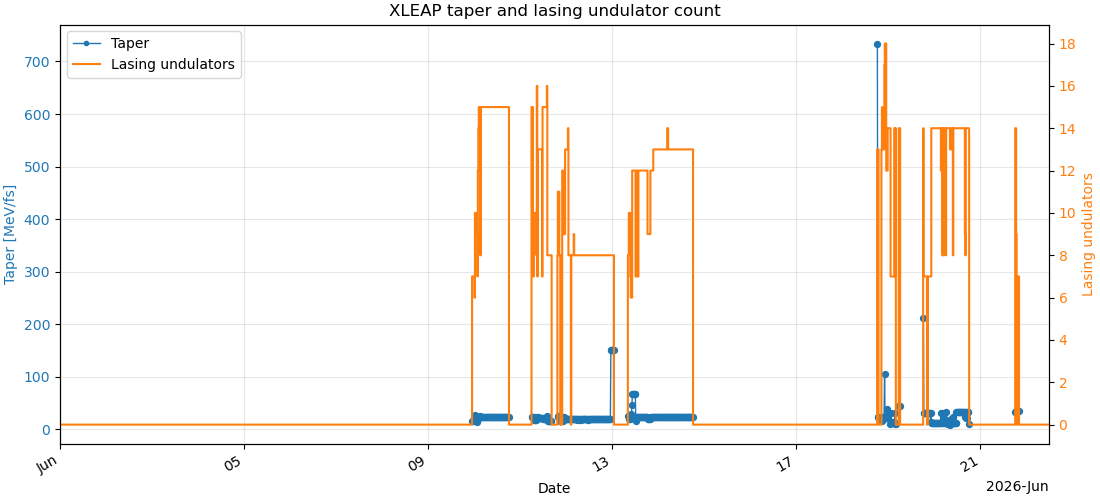

In [33]:
get_ipython().run_line_magic('matplotlib', 'widget')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

xleap_data = get_xleap_data(start, end)
xleap_df = pd.DataFrame(xleap_data).set_index('datetime').sort_index()

fig, taper_ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
und_ax = taper_ax.twinx()

xleap_mask = xleap_df['xleap_on']
taper_ax.plot(
    xleap_df.index,
    xleap_df['taper'],
    marker='o',
    markersize=3,
    linewidth=1,
    color='tab:blue',
    label='Taper',
)
und_ax.step(
    xleap_df.index,
    xleap_df['n_und'],
    where='mid',
    linewidth=1.5,
    color='tab:orange',
    label='Lasing undulators',
)

if xleap_mask.any():
    taper_ax.scatter(
        xleap_df.index[xleap_mask],
        xleap_df.loc[xleap_mask, 'taper'],
        s=18,
        color='tab:blue',
        zorder=3,
    )

taper_ax.set_xlim(xleap_df.index.min(), xleap_df.index.max())

taper_ax.set_title('XLEAP taper and lasing undulator count')
taper_ax.set_xlabel('Date')
taper_ax.set_ylabel('Taper [MeV/fs]', color='tab:blue')
und_ax.set_ylabel('Lasing undulators', color='tab:orange')
und_ax.yaxis.set_major_locator(MaxNLocator(integer=True))
taper_ax.tick_params(axis='y', labelcolor='tab:blue')
und_ax.tick_params(axis='y', labelcolor='tab:orange')
taper_ax.grid(True, alpha=0.3)

locator = mdates.AutoDateLocator()
taper_ax.xaxis.set_major_locator(locator)
taper_ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

lines = taper_ax.get_lines() + und_ax.get_lines()
labels = [line.get_label() for line in lines]
taper_ax.legend(lines, labels, loc='upper left')

fig.autofmt_xdate()
plt.show()


In [34]:
# Quick check of the taper calculation for a single time point: June 10 at 4